### Imports

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

### Data Cleaning and Feature Selction

In [ ]:
print("Starting data ingestion...")
# 1. Fetch data
# fetch dataset 296: Diabetes 130-US hospitals for years 1999-2008
diabetes = fetch_ucirepo(id=296)

# data (as pandas dataframes)
X = diabetes.data.features
y = diabetes.data.targets

df = pd.concat([X, y], axis=1)
    
# Filter out missing readmitted (if any)
df = df.dropna(subset=['readmitted'])
    
print("Data loaded. Shape:", df.shape)

# 2. Data Processing
print("Processing data...")
# Convert 'readmitted' to a binary target: 1 if '<30', 0 otherwise
df['target'] = df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)
    
# Select features based on the proposal
features = ['age', 'time_in_hospital', 'num_procedures', 'num_medications']
    
# Process 'age' from categorical '[0-10)' to numerical midpoint
def parse_age(age_str):
    if pd.isna(age_str):
        return np.nan
    age_str = str(age_str).replace('[', '').replace(')', '')
    parts = age_str.split('-')
    if len(parts) == 2:
        return (int(parts[0]) + int(parts[1])) / 2
    return np.nan

df['age_num'] = df['age'].apply(parse_age)
    
# Final feature set
selected_features = ['age_num', 'time_in_hospital', 'num_procedures', 'num_medications']
analysis_df = df[selected_features + ['target']].copy()
    
# Drop rows with NaN in these specific features
analysis_df = analysis_df.dropna()
print("Processed data shape:", analysis_df.shape)

# 3. Visualizations
print("Generating visualizations...")
    
# Setting up the visual style
sns.set_theme(style="whitegrid")

Starting data ingestion...
Data loaded. Shape: (101766, 48)
Processing data...
Processed data shape: (101766, 5)
Generating visualizations...


c:\Users\Lucca\Hospital\Hospital-Readmission-Risk\.venv\Lib\site-packages\ucimlrepo\fetch.py:97: DtypeWarning: Columns (0: payer_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


### Figure 1

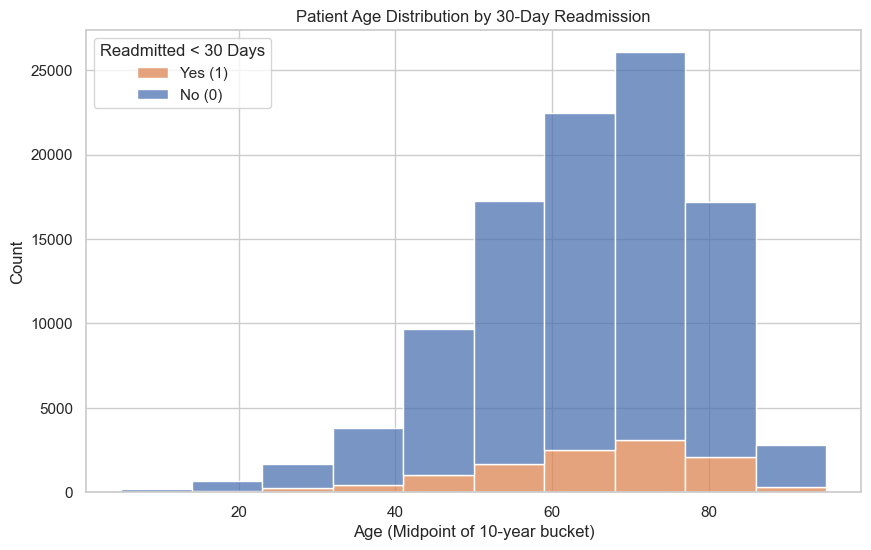

In [4]:
plt.figure(figsize=(10, 6))
sns.histplot(data=analysis_df, x='age_num', hue='target', multiple="stack", bins=10)
plt.title('Patient Age Distribution by 30-Day Readmission')
plt.xlabel('Age (Midpoint of 10-year bucket)')
plt.ylabel('Count')
plt.legend(title='Readmitted < 30 Days', labels=['Yes (1)', 'No (0)'])
plt.savefig('../visualizations/age_distribution.png')
plt.show()
plt.close()

### Figure 2

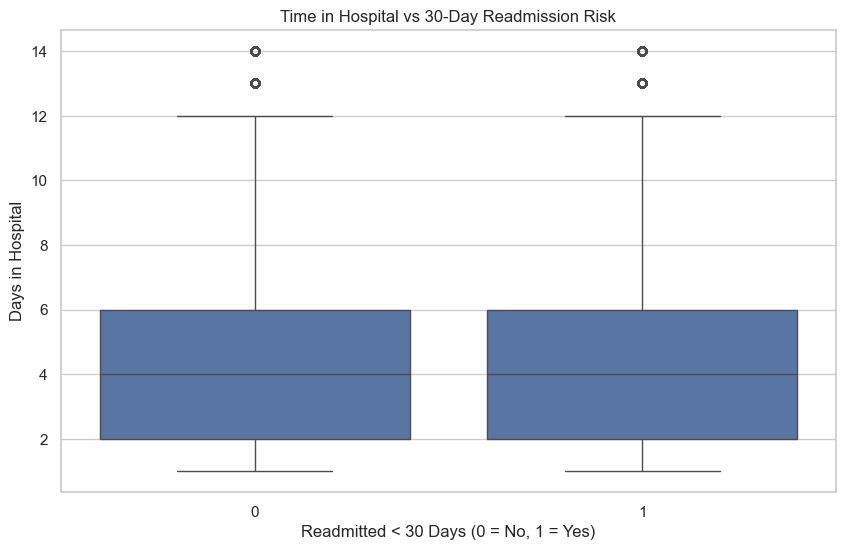

In [7]:
# Plot 2: Time in Hospital vs Readmission
plt.figure(figsize=(10, 6))
sns.boxplot(x='target', y='time_in_hospital', data=analysis_df)
plt.title('Time in Hospital vs 30-Day Readmission Risk')
plt.xlabel('Readmitted < 30 Days (0 = No, 1 = Yes)')
plt.ylabel('Days in Hospital')
plt.savefig('../visualizations/time_in_hospital_boxplot.png')
plt.show()
plt.close()